<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


In [2]:
# Carga de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, RobustScaler
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go



## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [3]:
# Carga de datos
from sklearn.datasets import load_wine
df = load_wine()
df = pd.DataFrame(df.data, columns=df.feature_names) # Convierte en data frame

print("Primeras filas del dataset:")
df.head(10) # Muestra  primeras filas

Primeras filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


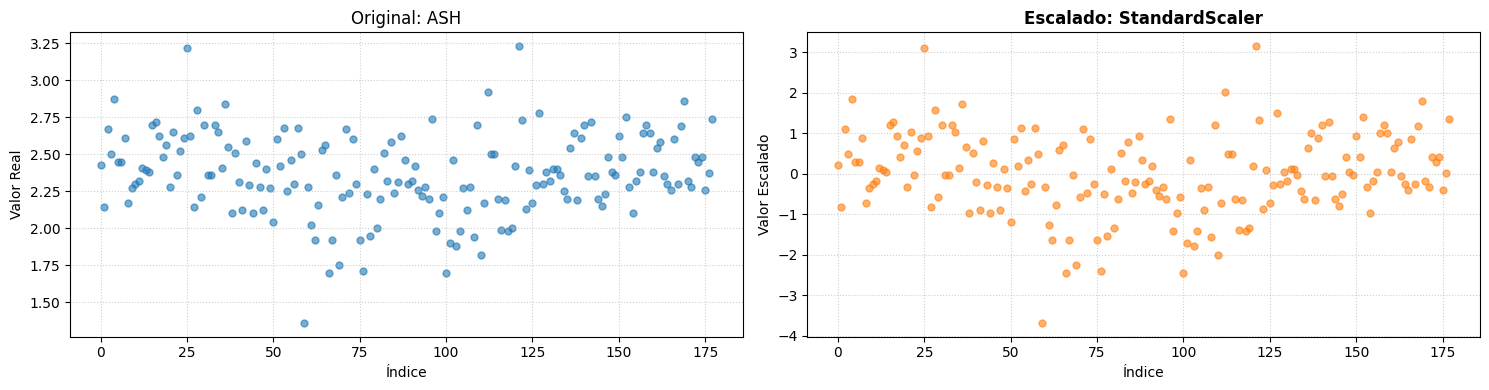

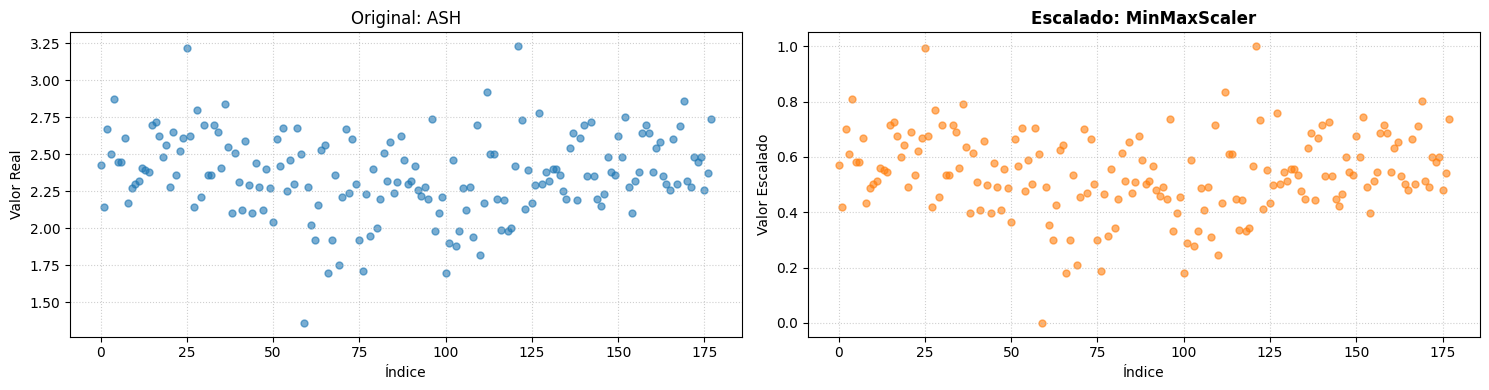

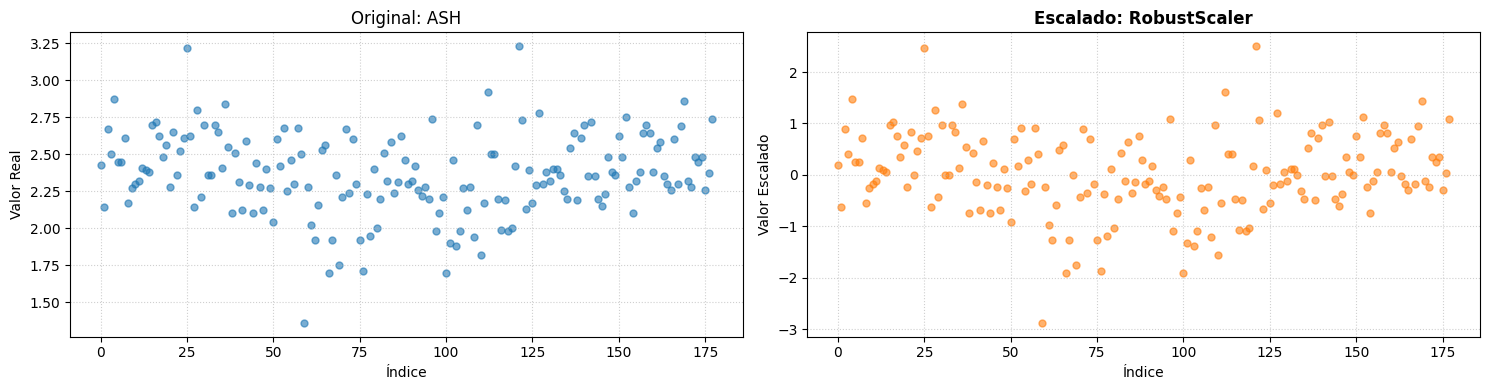

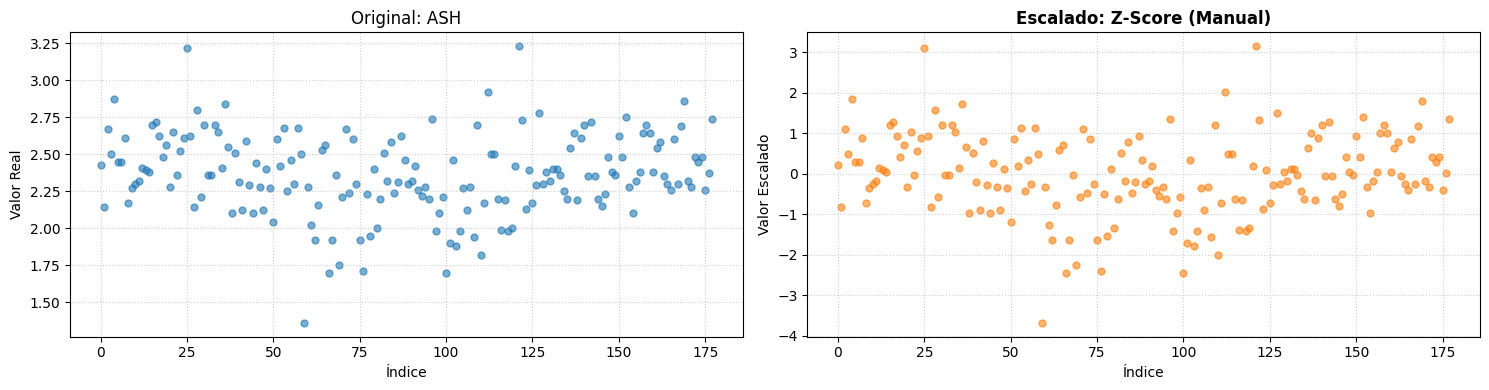

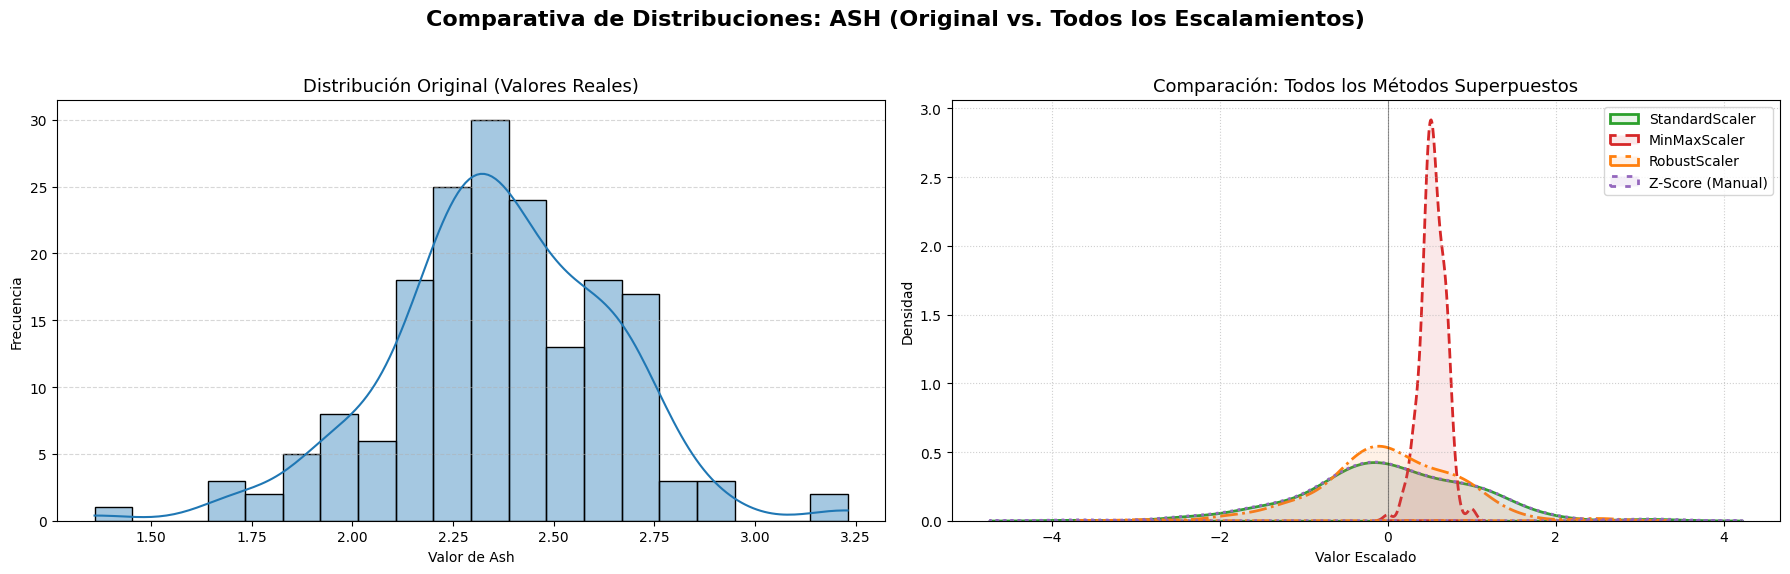

In [4]:
# Seleccionar variables
features = ['alcohol', 'ash', 'total_phenols']
data_subset = df[features]

# 2. Diccionario de escalamientos (Incluyendo todos los solicitados)
scalers = {
    'StandardScaler': StandardScaler().fit_transform(data_subset),
    'MinMaxScaler': MinMaxScaler().fit_transform(data_subset),
    'RobustScaler': RobustScaler().fit_transform(data_subset),
    'Z-Score (Manual)': stats.zscore(data_subset)
}

indices = np.arange(len(df))

# Define 'variable' and 'col_idx' for plotting (e.g., 'ash')
variable = 'ash'
col_idx = features.index(variable)

datos_originales = df[variable].values

# 3. Graficación limpia (Sin cuadros de texto)
for name, transformed_data in scalers.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

    # Extraer columna 'ash' del array transformado
    values_scaled = transformed_data[:, col_idx]

    # --- Gráfica Izquierda: Datos Originales ---
    ax1.scatter(indices, datos_originales, alpha=0.6, color='tab:blue', s=25)
    ax1.set_title(f'Original: {variable.upper()}', fontsize=12)
    ax1.set_xlabel('Índice')
    ax1.set_ylabel('Valor Real')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- Gráfica Derecha: Datos Escalados ---
    ax2.scatter(indices, values_scaled, alpha=0.6, color='tab:orange', s=25)
    ax2.set_title(f'Escalado: {name}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Índice')
    ax2.set_ylabel('Valor Escalado')
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de la figura (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Comparativa de Distribuciones: {variable.upper()} (Original vs. Todos los Escalamientos)',
             fontsize=16, fontweight='bold')

# --- PANEL 1: DATOS ORIGINALES ---
sns.histplot(datos_originales, kde=True, color='tab:blue', ax=ax1, bins=20, alpha=0.4)
ax1.set_title('Distribución Original (Valores Reales)', fontsize=13)
ax1.set_xlabel('Valor de Ash')
ax1.set_ylabel('Frecuencia')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- PANEL 2: COMPARATIVA DE TODOS LOS ESCALAMIENTOS ---
# Definimos colores para diferenciar los métodos
colores = ['tab:green', 'tab:red', 'tab:orange', 'tab:purple']
estilos = ['-', '--', '-.', ':']

for i, (name, transformed_data) in enumerate(scalers.items()):
    # Extraer la columna 'ash' del método actual
    values_scaled = transformed_data[:, col_idx]

    # Graficamos la línea de densidad (KDE) para que no se amontonen tantas barras
    sns.kdeplot(values_scaled, ax=ax2, label=name, color=colores[i],
                linestyle=estilos[i], linewidth=2, fill=True, alpha=0.1)

ax2.set_title('Comparación: Todos los Métodos Superpuestos', fontsize=13)
ax2.set_xlabel('Valor Escalado')
ax2.set_ylabel('Densidad')
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4) # Eje central
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Cuando se observan los sacatter no hay algo más se aprecia más diferencia que la escala y es justo lo que se busca, sin embargo, cuando se ponen en la misma gráfica todos los métodos de escalamiento se observa que el min-max no es adecuando para escalar los datos debido a su comportamiento que puede derivare de la presencia de valores muy extremos, mientras que los otros 3 métodos sí tienen comportamientos muy similares, especialmente Standardscaler y Z-score

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [5]:
# Carga de datos
from sklearn.datasets import load_diabetes
df = load_diabetes()
df = pd.DataFrame(df.data, columns=df.feature_names) # Convierte en data frame

print("Primeras filas del dataset:")
df.head(10) # Muestra  primeras filas

Primeras filas del dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504


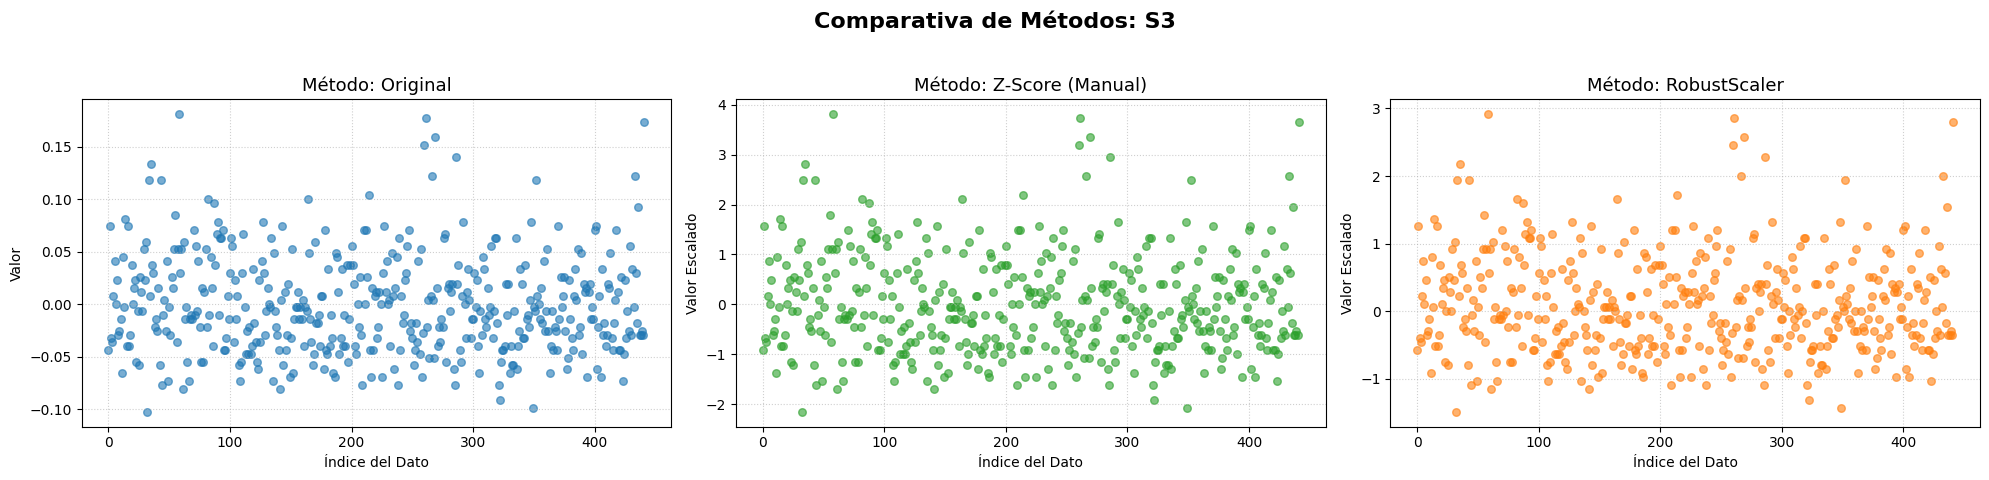

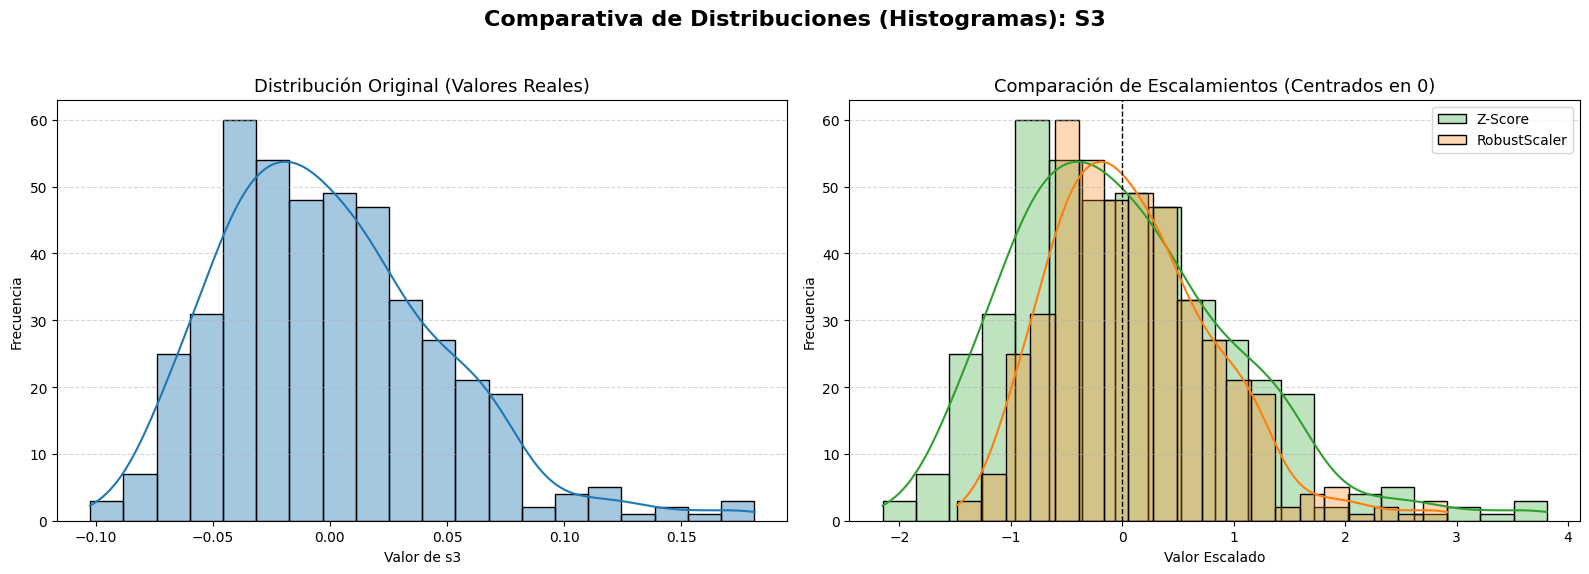

In [29]:
# Seleccionar variables
features = ['bp', 's3', 's6']
data_subset = df[features]

# Define 'variable' and 'col_idx' for plotting (e.g., 'ash')
variable = 's3'
col_idx = features.index(variable)

datos_originales = df[variable].values

# 1. Definimos los métodos específicos que queremos comparar
metodos_a_graficar = ['Original', 'Z-Score (Manual)', 'RobustScaler']
colores = ['tab:blue', 'tab:green', 'tab:orange']

# 2. Creamos la figura con una sola fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f'Comparativa de Métodos: {variable.upper()}', fontsize=16, fontweight='bold')

for i, metodo in enumerate(metodos_a_graficar):
    ax = axes[i]

    # Extraer los datos correctos del diccionario o del dataframe original
    if metodo == 'Original':
        values = datos_originales
    else:
        # Extraemos la columna 's3' (col_idx) de la matriz transformada
        values = scalers[metodo][:, col_idx]

    # Graficar Scatter
    ax.scatter(indices, values, alpha=0.6, color=colores[i], s=30)

    # Configuración de cada subgráfica
    ax.set_title(f'Método: {metodo}', fontsize=13)
    ax.set_xlabel('Índice del Dato')
    ax.set_ylabel('Valor' if i == 0 else 'Valor Escalado')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Crear la figura con 2 subplots (Histogramas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Comparativa de Distribuciones (Histogramas): {variable.upper()}', fontsize=16, fontweight='bold')

# --- 1. HISTOGRAMA IZQUIERDO: Datos Originales ---
sns.histplot(datos_originales, kde=True, color='tab:blue', ax=ax1, bins=20, alpha=0.4)
ax1.set_title('Distribución Original (Valores Reales)', fontsize=13)
ax1.set_xlabel('Valor de s3')
ax1.set_ylabel('Frecuencia')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- 2. HISTOGRAMA DERECHO: Datos Escalados Superpuestos ---
# Superponemos Z-Score y RobustScaler para ver la diferencia de "ajuste"
sns.histplot(scalers['Z-Score (Manual)'][:, col_idx], kde=True, color='tab:green',
             label='Z-Score', ax=ax2, bins=20, alpha=0.3)
sns.histplot(scalers['RobustScaler'][:, col_idx], kde=True, color='tab:orange',
             label='RobustScaler', ax=ax2, bins=20, alpha=0.3)

ax2.set_title('Comparación de Escalamientos (Centrados en 0)', fontsize=13)
ax2.set_xlabel('Valor Escalado')
ax2.set_ylabel('Frecuencia')
ax2.axvline(0, color='black', linestyle='--', linewidth=1) # Línea en el centro
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Al igual que en el punto anteriror, el resultado de ambos métodos se ve demasiado similar. Lo anterior nos indica que caulquiera de los métodos trabaja muy bien para escalar la variable s3 (variable graficada), adicionalmente, vemos que robust escaler tiene un breve movimiento hacia la derecha, concentrando un poco más los datos hacia la media, sin embargo, no hay más para interpretar que decir, esto quiere decir que los datos con los dos escalados tuvieron un comportamiento muy similar (por no decir que igual).

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

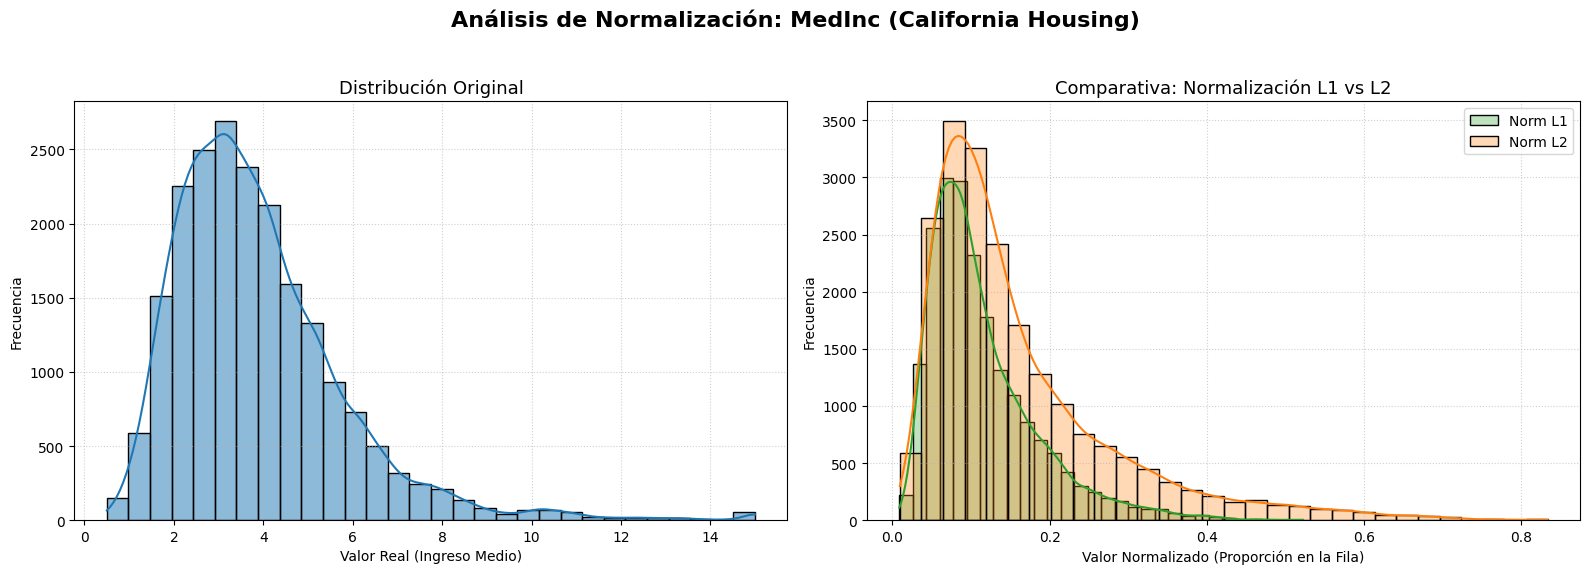

In [38]:
# 1. Carga de datos
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
features = ['MedInc', 'AveRooms', 'HouseAge']
data_subset = df[features]
variable = 'MedInc'

# 2. Aplicar Normalización L1 y L2
# L1: La suma de los valores absolutos de la fila es 1
data_l1 = Normalizer(norm='l1').fit_transform(data_subset)
# L2: La suma de los cuadrados de la fila es 1 (distancia euclidiana)
data_l2 = Normalizer(norm='l2').fit_transform(data_subset)

# Convertir a DataFrame para graficar la columna seleccionada
df_l1 = pd.DataFrame(data_l1, columns=features)
df_l2 = pd.DataFrame(data_l2, columns=features)

# 3. Graficación en dos paneles (Histogramas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Análisis de Normalización: {variable} (California Housing)', fontsize=16, fontweight='bold')

# --- Panel Izquierdo: Datos Originales ---
sns.histplot(data_subset[variable], kde=True, color='tab:blue', ax=ax1, bins=30, alpha=0.5)
ax1.set_title('Distribución Original', fontsize=13)
ax1.set_xlabel('Valor Real (Ingreso Medio)')
ax1.set_ylabel('Frecuencia')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Panel Derecho: Normalización L1 vs L2 ---
sns.histplot(df_l1[variable], kde=True, color='tab:green', label='Norm L1', ax=ax2, bins=30, alpha=0.3)
sns.histplot(df_l2[variable], kde=True, color='tab:orange', label='Norm L2', ax=ax2, bins=30, alpha=0.3)

ax2.set_title('Comparativa: Normalización L1 vs L2', fontsize=13)
ax2.set_xlabel('Valor Normalizado (Proporción en la Fila)')
ax2.set_ylabel('Frecuencia')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

con respecto a la original se ve que ambos métodos de normalización funcionan para eliminar ese valor atípico al final, sin embargo, se puede observar que L2 tiene un comportamiento menos extremo que L1, sin embargo, esa suavidad de ve en una cola más extensa que es más similar al comportamiento de los datos, situación que es preferible.


## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

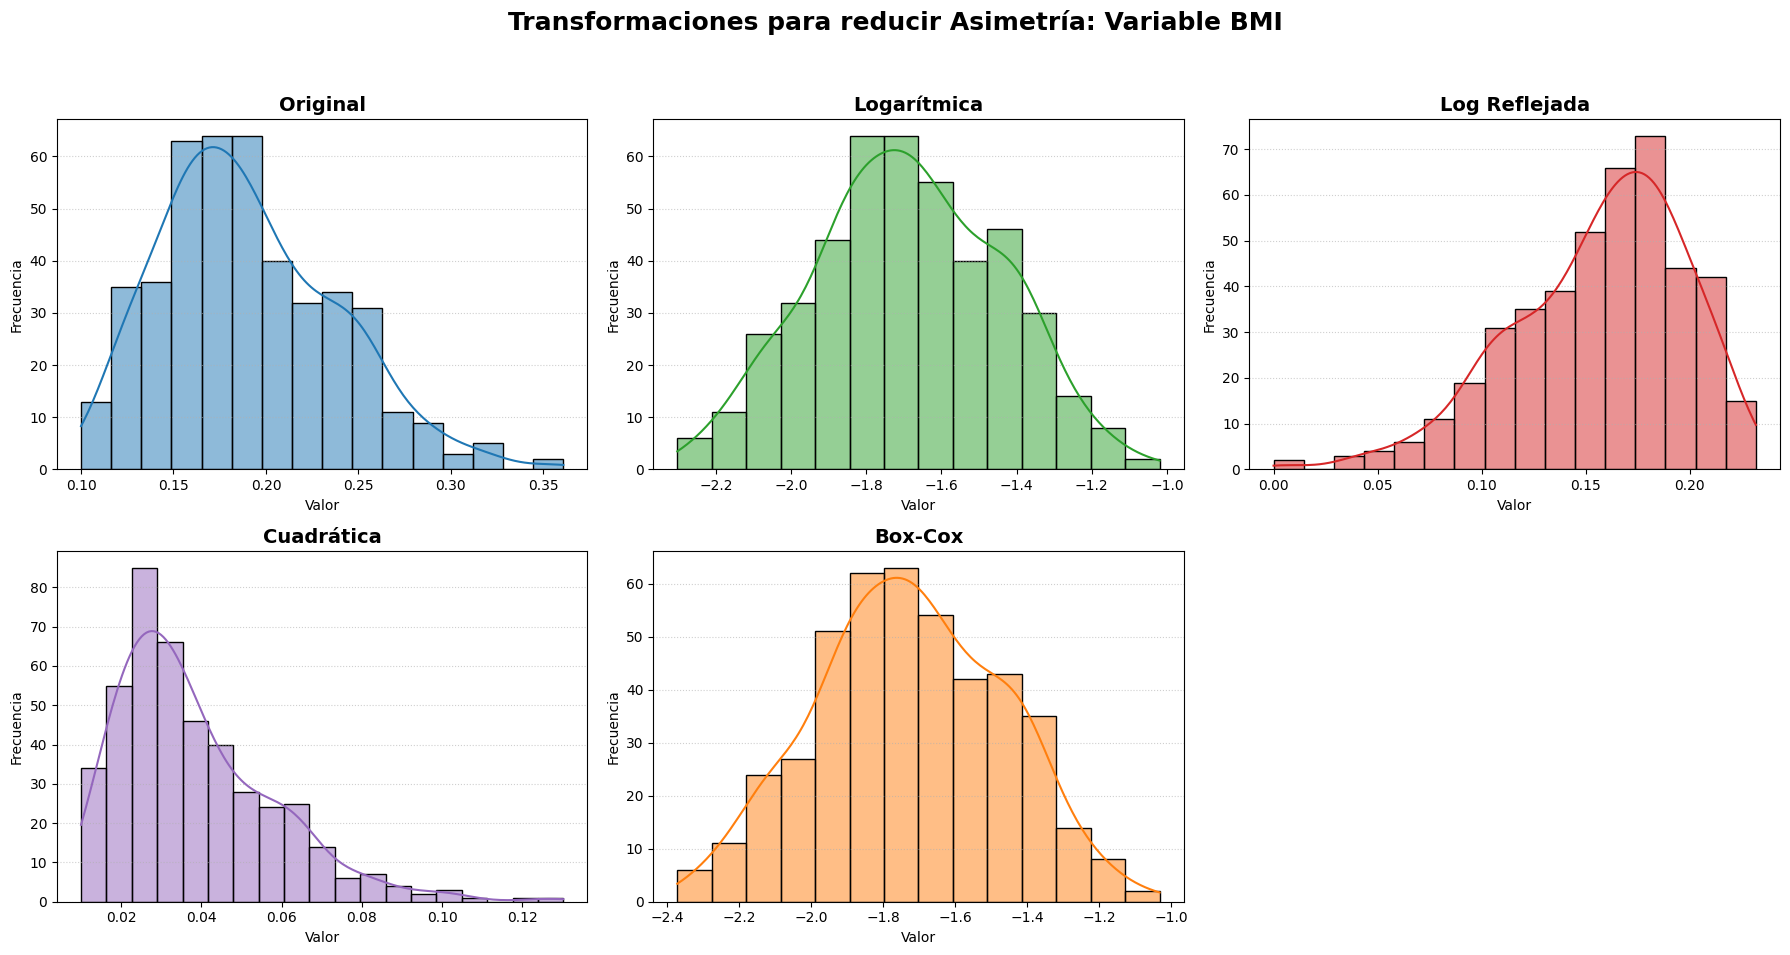

In [40]:
# carga de datos
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Seleccionamos 'bmi' (Índice de Masa Corporal) para el análisis
variable = 'bmi'
datos_orig = df[variable]

# transformaciones matemáticos
# para que todos sean positivos y las transformaciones (log, box-cox) funcionen.
shift = abs(datos_orig.min()) + 0.1
x = datos_orig + shift

# Logarítmica
trans_log = np.log(x)

# Logarítmica Reflejada (Reflejamos sobre el máximo para corregir asimetría)
trans_reflejada = np.log(x.max() + 1 - x)

# Cuadrática
trans_cuad = np.square(x)

# Box-Cox (Busca automáticamente la mejor potencia lambda)
# boxcox devuelve (datos_transformados, lambda)
trans_boxcox, _ = stats.boxcox(x)

# VISUALIZACIÓN
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Transformaciones para reducir Asimetría: Variable {variable.upper()}',
             fontsize=18, fontweight='bold')

# Lista de datos y títulos para iterar
titles = ['Original', 'Logarítmica', 'Log Reflejada', 'Cuadrática', 'Box-Cox']
data_list = [x, trans_log, trans_reflejada, trans_cuad, trans_boxcox]
colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:purple', 'tab:orange']

# Aplanamos los ejes para iterar fácilmente
axes_flat = axes.flatten()

for i in range(5):
    sns.histplot(data_list[i], kde=True, ax=axes_flat[i], color=colors[i], alpha=0.5)
    axes_flat[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes_flat[i].set_xlabel('Valor')
    axes_flat[i].set_ylabel('Frecuencia')
    axes_flat[i].grid(axis='y', linestyle=':', alpha=0.6)

# Eliminar el último recuadro que sobra (6to eje)
fig.delaxes(axes_flat[5])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

En base a los resultados que se obtuvieron, se determina que las mejores transformaciones para la base de datos son la logaritmina y la box-cox debido a que son las que asemejan el comportamiento más cercano a la normalidad teniendo comportamientos muy similares las dos transformaciones. La transformación Log reflejada y la cuadrática no presentan colas como el comportamiento de los datos originales, situación que no se busca.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos Heart Disease desde la librería ucimlrepo usando load_dataset("heart_disease = fetch_ucirepo(id=45)").

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

Variables disponibles: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


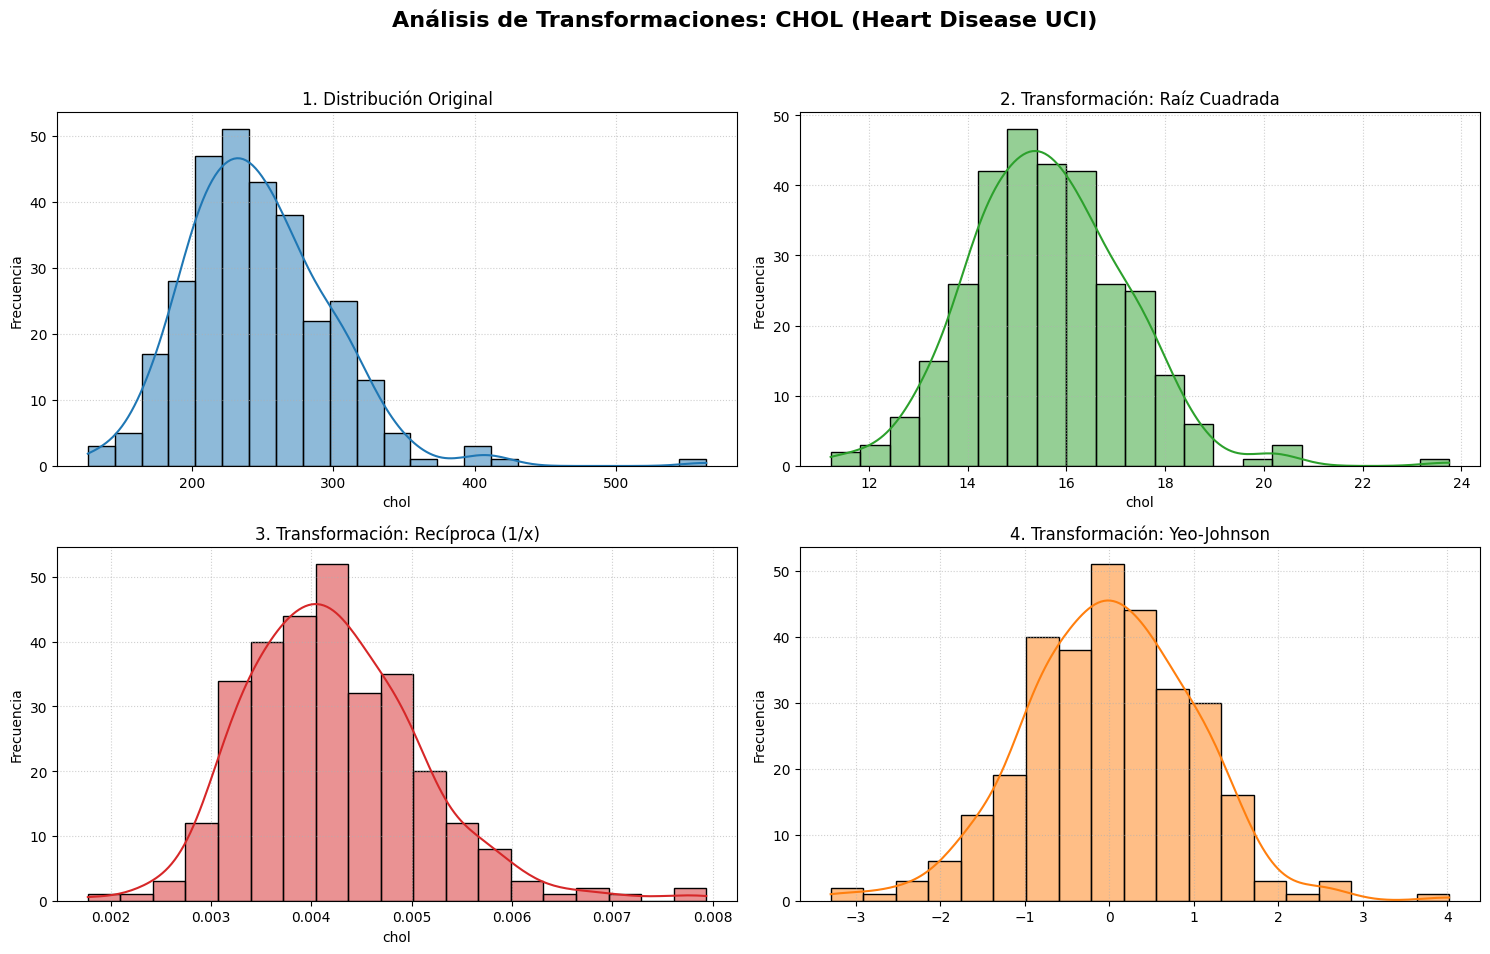

In [45]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import PowerTransformer

# Carga de datos
# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Datos (features) en formato pandas DataFrame
df = heart_disease.data.features

# Identificar variables disponibles
print("Variables disponibles:", df.columns.tolist())

# Selección de variables y transformaciones
# Seleccionamos 'chol' (colesterol)
variable = 'chol'
data_orig = df[variable].dropna() # Eliminamos nulos si existieran

# a. Raíz Cuadrada
trans_sqrt = np.sqrt(data_orig)

# b. Recíproca (1/x)
trans_recip = 1 / data_orig

# c. Yeo-Johnson
# PowerTransformer espera un array 2D, por eso usamos .values.reshape(-1, 1)
pt = PowerTransformer(method='yeo-johnson')
trans_yeo = pt.fit_transform(data_orig.values.reshape(-1, 1)).flatten()

# Gráficas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Análisis de Transformaciones: {variable.upper()} (Heart Disease UCI)',
             fontsize=16, fontweight='bold')

# --- Original ---
sns.histplot(data_orig, kde=True, ax=axes[0, 0], color='tab:blue', alpha=0.5)
axes[0, 0].set_title('1. Distribución Original', fontsize=12)

# --- Raíz Cuadrada ---
sns.histplot(trans_sqrt, kde=True, ax=axes[0, 1], color='tab:green', alpha=0.5)
axes[0, 1].set_title('2. Transformación: Raíz Cuadrada', fontsize=12)

# --- Recíproca ---
sns.histplot(trans_recip, kde=True, ax=axes[1, 0], color='tab:red', alpha=0.5)
axes[1, 0].set_title('3. Transformación: Recíproca (1/x)', fontsize=12)

# --- Yeo-Johnson ---
sns.histplot(trans_yeo, kde=True, ax=axes[1, 1], color='tab:orange', alpha=0.5)
axes[1, 1].set_title('4. Transformación: Yeo-Johnson', fontsize=12)

# Ajustes generales
for ax in axes.flat:
    ax.set_ylabel('Frecuencia')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Analizando graficamente el resultado, se evidencia que la mejor transformación es la transformación de Yeo-johnson debido a que ella logra una normalización más homogenea de los datos en comparación con los otros dos métodos, donde no se observa ese comportamiento debido a un leve desplazamiento de los datos hacia el lado izquierdo y una pequeña cola al lado derecho de los datos.